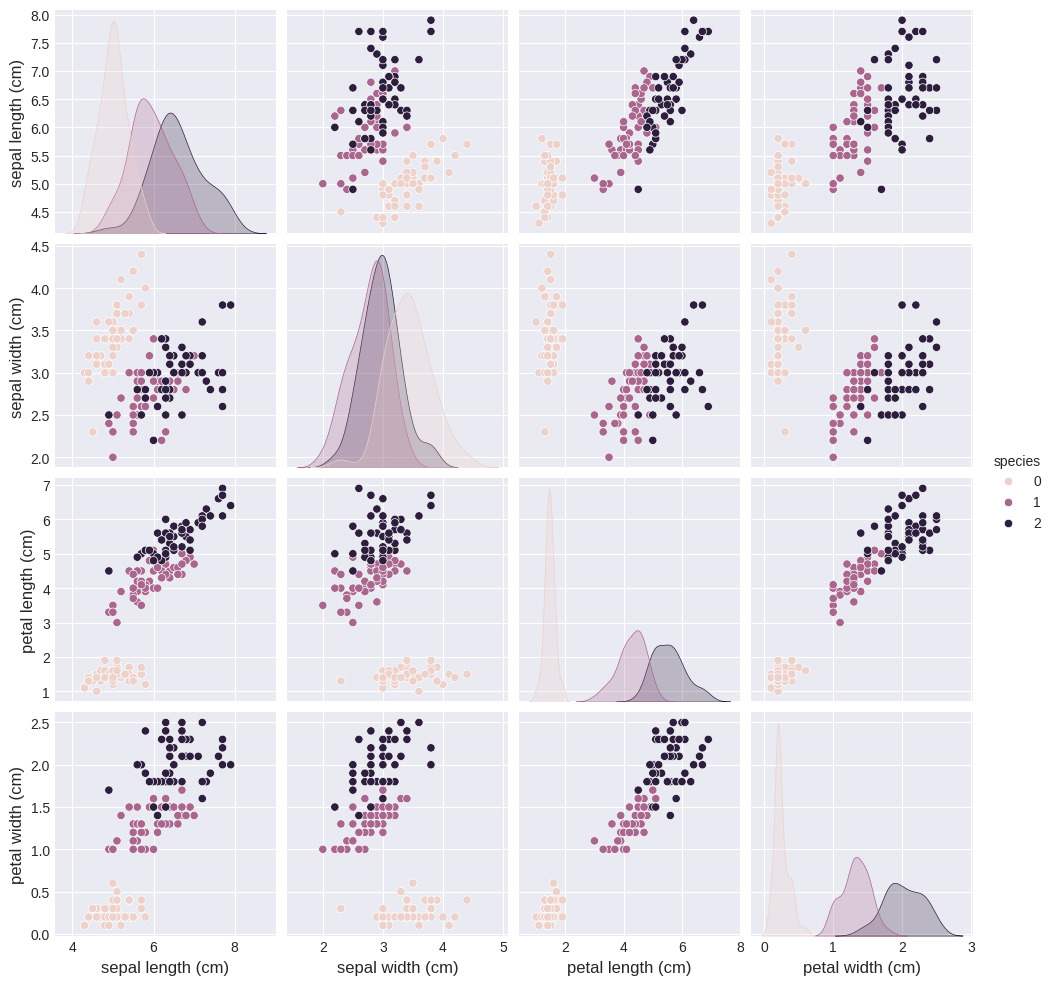

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



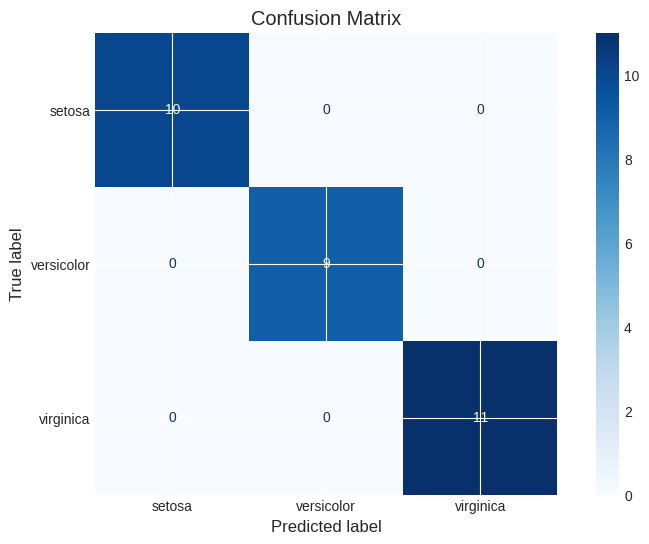

In [3]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# =========================================
# LOAD IRIS DATASET
# =========================================

iris = load_iris()

X = iris.data

y = iris.target

target_names = iris.target_names


# =========================================
# CREATE DATAFRAME
# =========================================

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df['species'] = y


# =========================================
# DATA VISUALIZATION
# =========================================

sns.pairplot(
    df,
    hue='species'
)

plt.show()


# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================================
# FEATURE SCALING
# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# =========================================
# LOGISTIC REGRESSION MODEL
# =========================================

model = LogisticRegression(
    max_iter=200
)

model.fit(X_train, y_train)


# =========================================
# PREDICTIONS
# =========================================

y_pred = model.predict(X_test)


# =========================================
# ACCURACY
# =========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)


# =========================================
# CLASSIFICATION REPORT
# =========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)


# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()